# QSP Angle Finder


In [1]:
import numpy as np
from matplotlib import pyplot as plt

from guppyalgos.utils import ChebyshevPolynomial, QSPAngleFinder
from guppyalgos.utils import FourierPolynomial, GQSPAngleFinder

## Computing QSP phase factors for a Gibbs distribution
Here we optimize the QSP angles for a Gibbs distribution. Since the Gibbs distribution is not a polynomial, we first have to find a Chebyshev approximation of the Gibbs function for which we then can find the QSP angles. The implementation is based on https://arxiv.org/abs/2002.11649. 

In [2]:
# Target functions 

def _gibbs_fun(x, beta):
    return np.exp(-beta * x)


def generate_gibbs_fun(beta):
    def fun(x):
        return _gibbs_fun(x, beta)

    return fun


def symmetrize_fun(fun, parity=0):
    if parity == 0:

        def neg_fun(x):
            return fun(-x)

        def pos_fun(x):
            return fun(x)

    if parity == 1:

        def neg_fun(x):
            return -fun(-x)

        def pos_fun(x):
            return fun(x)

    def sfun(x):
        if x < 0:
            return neg_fun(x)
        if x >= 0:
            return pos_fun(x)

    return np.vectorize(sfun)

In [3]:
beta = 2.5

gibbs_fun = generate_gibbs_fun(beta)
sym_gibbs_fun = symmetrize_fun(gibbs_fun, 0)
antisym_gibbs_fun = symmetrize_fun(gibbs_fun, 1)

### Step 1: Function approximation
First, we need to approximate our target function with a Chebyshev polynomial. We
choose an even extension of the inverse exponential 
and approximate it with the degree-$d$ Chebyshev polynomial
$$
    f_d(x) = \sum_{k=0}^{d} c_k T_k(x).
$$

The method `chebyshev_polynomial` can perform this approximation, compute the
coefficients $c_n$ and returns the Chebyshev polynomial. As target we consider a symmetrized version of the Gibbs distribution.


In [6]:
d_phi = 16
d_cheb = d_phi

sym_gibbs_cheb = ChebyshevPolynomial(sym_gibbs_fun, d_cheb)
sym_gibbs_cheb.error

np.float64(0.08752003120788343)

### Step 2: Optimize QSP angles

In [7]:
qsp_optimizer = QSPAngleFinder(d_phi=d_phi, target_polynomial=sym_gibbs_cheb)
qsp_optimizer.opt_error

np.float64(1.143952755992354e-09)

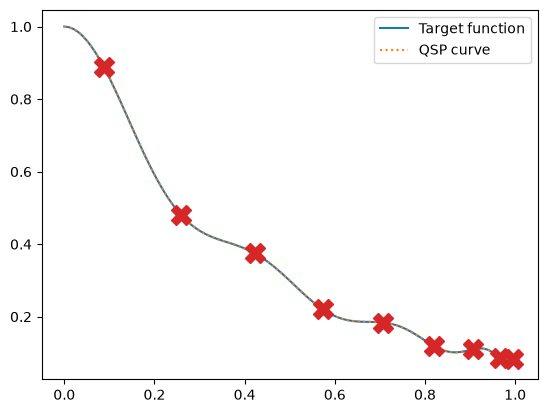

In [8]:
x_vals=np.linspace(0, 1, 100)
f_vals = qsp_optimizer(x=x_vals)
plt.plot(x_vals, qsp_optimizer.target_polynomial(x_vals), label="Target function")
plt.plot(x_vals, f_vals, linestyle="dotted", label="QSP curve")
for x_j in qsp_optimizer.x_Chebyshev_roots:
    plt.plot(
        [x_j],
        [qsp_optimizer.target_polynomial(x_j)],
        color="C3",
        marker="X",
        markersize=15,
    )
plt.legend()
plt.show()

## Computing GQSP phase factors

Based on https://arxiv.org/pdf/2308.01501, also known as Fourier QSP https://arxiv.org/pdf/2206.02826.

Given a function $f(z)=\sum_n c_n z^n$ with $c_n$ complex, it implements $f(U)$ of a unitary $U$ given as $U=e^{i H}$.

More generally, as in https://arxiv.org/pdf/2312.00723, one can use GQSP to perform $p(z)=\sum_n c_n T_n(z)$ on an Hermitian matrix, being $T_n$ the Chebyshev polynomials, by adding a reflection, i.e. using qubitization.

The protocol is the following:
1. Select target function and compute coefficients of Fourier series. Must be normalized.
2. Obtain auxiliary polynomial that satisfies unitary condition $|P(x)|^2+|Q(x)|^2=1$ $\forall x$.
3. Compute phase factors.

### Step 1: Target Function
We consider the function $e^{-\tau \pi |x|}$ and get the coefficients. With that we construct the Fourier function using the ```FourierPolynomial``` class.

In [ ]:
tau = 1.2
degree = 40

d_max = degree // 2
d_min = - degree // 2

f_coeffs = {
    k : (tau*(1+((-1)**(k+1))*np.exp(-np.pi*tau)))/(np.pi*(tau**2 + k**2))
    for k in range(d_min, d_max+1)
}

f = FourierPolynomial(f_coeffs, d_max, d_min)

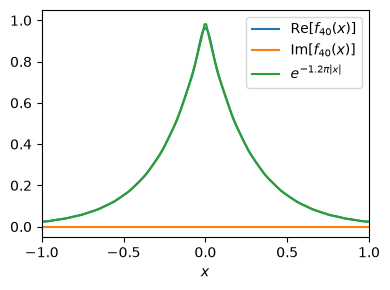

In [12]:
plt.figure(figsize=(4,3))
xax = np.linspace(-1, 1, 200)
plt.plot(xax, f(xax).real, label=rf'Re$[f_{{{degree}}}(x)]$', color='C0')
plt.plot(xax, f(xax).imag, label=rf'Im$[f_{{{degree}}}(x)]$', color='C1')
plt.plot(xax, np.exp(-tau*np.pi*np.abs(xax)), label=rf'$e^{{-{float(tau):.3} \pi |x|}}$', color='C2')
plt.legend()
plt.xlim(-1, 1)
plt.ylim(-0.05,1.05)
plt.xlabel(r'$x$')
plt.tight_layout()

### Step 2: Obtaining auxiliary polynomial and phase factors with GQSPAngleFinder
Once initialized the instance of ```GQSPAngleFinder``` for the target Fourier series, it first computes the complementary polynomial following the Proof of Lemma 4 in https://arxiv.org/pdf/2206.02826. Then, it computes the phase factors following the constructive method showed in https://arxiv.org/pdf/2308.01501.

Both are exact methods, but as we increase the degree the numerical precision leads to some errors. 

In [13]:
angle_finder = GQSPAngleFinder(f)

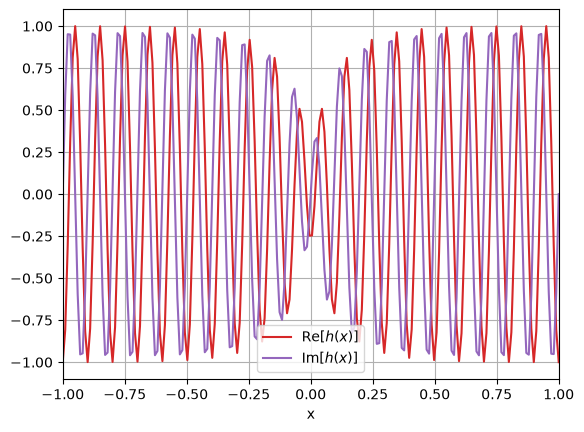

In [14]:
# Let us plot the complementary function h(x)

q = angle_finder.complementary_polynomial
plt.plot(xax, q(xax).real, label=r'Re$[ h(x) ]$', color='C3')
plt.plot(xax, q(xax).imag, label=r'Im$[ h(x) ]$', color='C4')
plt.xlim(-1,1)
plt.xlabel(r'x')
plt.grid()
plt.legend()

In [15]:
# Check unitary condition is satisfied
np.square(np.abs(f(xax))) + np.square(np.abs(q(xax)))

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

### Step 3: Getting the phase factors

In [16]:
phase_factors = angle_finder.phase_factors